In [1]:
# Import Required Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBRegressor

# 1 - Baseline Model

## 1a) PuckPedia Data Preprocessing

### Reduce DataFrame to players who are in the final year of their contracts.

In [ ]:
# Read in data file.
initial_df = pd.read_excel("../data/PuckPediaData.xlsx")

In [3]:
# Remove unnecessary columns.
df = initial_df.drop(columns=["Cap Rank", "Unnamed: 2", "% of Cap at Signing", "Signing Agent", "Signing GM", "Level", "UFA Year", "$/P", 'G60', 'P60', 
                              "Status", "Clauses", "Draft Year", "Draft Round", "Cap Hit", "Signing Age", "PPG", "+/-", 'xGF%', 'relxGF%'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Player Name     3720 non-null   object 
 1   Birthdate       3720 non-null   object 
 2   Pos             3720 non-null   object 
 3   Shot            3720 non-null   object 
 4   W(lbs)          3720 non-null   int64  
 5   H(f)            3720 non-null   object 
 6   Draft Position  3263 non-null   float64
 7   Length          3720 non-null   int64  
 8   AAV             3720 non-null   int64  
 9   Structure       3720 non-null   object 
 10  Start Year      3720 non-null   object 
 11  Signing Status  2933 non-null   object 
 12  Expiry Year     3720 non-null   object 
 13  Expiry Status   3720 non-null   object 
 14  GP              2977 non-null   float64
 15  G               2977 non-null   float64
 16  A               2977 non-null   float64
 17  P               2977 non-null   f

In [4]:
# Reformat Year Columns
initial_df['Start Year'] = initial_df['Start Year'].str.split('-').str[1].astype(int) + 2000
initial_df['Expiry Year'] = initial_df['Expiry Year'].str.split('-').str[1].astype(int) + 2000
initial_df['Season'] = initial_df['Season'].astype(int)

df['Start Year'] = df['Start Year'].str.split('-').str[1].astype(int) + 2000
df['Expiry Year'] = df['Expiry Year'].str.split('-').str[1].astype(int) + 2000
df['Season'] = df['Season'].astype(int)

# Keep player-seasons where the Expiry Year matches the Season
contract_year_df = df[df['Season'] == initial_df['Expiry Year']].copy()

In [5]:
# Create "Next Year" Column
contract_year_df['Next_Year'] = contract_year_df['Season'] + 1

# Contract lookup table
next_contract_lookup = (
    df[['Player Name', 'Start Year', 'AAV', 'Length']]
    .drop_duplicates(subset=['Player Name', 'Start Year'])
    .rename(columns={'AAV': 'next_aav', 'Length': 'next_length'})
)

# Create "Next AAV" and "Next Length" Columns
contract_year_df = contract_year_df.merge(
    next_contract_lookup,
    left_on=['Player Name', 'Next_Year'],
    right_on=['Player Name', 'Start Year'],
    how='left'
)

# Drop players without valid future contracts
contract_year_df = contract_year_df.dropna(subset=['next_aav'])

# Drop players with no games played
contract_year_df = contract_year_df[contract_year_df['GP'] > 0]

In [6]:
print(contract_year_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 974 entries, 290 to 1482
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Player Name     974 non-null    object 
 1   Birthdate       974 non-null    object 
 2   Pos             974 non-null    object 
 3   Shot            974 non-null    object 
 4   W(lbs)          974 non-null    int64  
 5   H(f)            974 non-null    object 
 6   Draft Position  824 non-null    float64
 7   Length          974 non-null    int64  
 8   AAV             974 non-null    int64  
 9   Structure       974 non-null    object 
 10  Start Year_x    974 non-null    int64  
 11  Signing Status  774 non-null    object 
 12  Expiry Year     974 non-null    int64  
 13  Expiry Status   974 non-null    object 
 14  GP              974 non-null    float64
 15  G               974 non-null    float64
 16  A               974 non-null    float64
 17  P               974 non-null    float

### Finish preprocessing for analysis. 

In [7]:
# Rename necessary columns
contract_year_df = contract_year_df.rename(columns={'W(lbs)': 'weight_lbs', 'Draft Position': 'Draft_Position', 'GF%': 'GF_pct','CF%': 'CF_pct',})

# Reformat Player Name into Last_Name and First_Name
contract_year_df[['Last_Name', 'First_Name']] = contract_year_df['Player Name'].str.split(',', expand=True)

contract_year_df['First_Name'] = contract_year_df['First_Name'].str.strip()
contract_year_df['Last_Name'] = contract_year_df['Last_Name'].str.strip()

# Reformat height into a numerical format (inches), drop original column
contract_year_df['height_in'] = (
    contract_year_df['H(f)']
    .str.replace('"','', regex=False)
    .str.split("'")
    .apply(lambda x: int(x[0]) * 12 + int(x[1])))

# Reformat TOI variables into an integer (minutes)
contract_year_df['TOI_5x5'] = contract_year_df['TOI 5x5/g'].astype(str).str.split(':').apply(lambda x: int(x[0]) + int(x[1]) / 60)
contract_year_df['TOI_PP'] = contract_year_df['TOI PP/g'].astype(str).str.split(':').apply(lambda x: int(x[0]) + int(x[1]) / 60)
contract_year_df['TOI_PK'] = contract_year_df['TOI PK/g'].astype(str).str.split(':').apply(lambda x: int(x[0]) + int(x[1]) / 60)

contract_year_df['TOI_5x5'] = contract_year_df['TOI_5x5'].round(2)
contract_year_df['TOI_PP'] = contract_year_df['TOI_PP'].round(2)
contract_year_df['TOI_PK'] = contract_year_df['TOI_PK'].round(2)

# Reformat Birthdate as datetime
contract_year_df['Birthdate'] = pd.to_datetime(contract_year_df['Birthdate'])

# Encode the position column
contract_year_df['Pos_C'] = (contract_year_df['Pos'] == 'C').astype(int)
contract_year_df['Pos_D'] = (contract_year_df['Pos'] == 'D').astype(int)

# Encode the shot handedness column (left = 1)
contract_year_df['Shot'] = (contract_year_df['Shot'] == 'l').astype(int)

# Encode structure column (2-way = 1)
contract_year_df['Two_Way'] = (contract_year_df['Structure'] == '2-way').astype(int)

# Encode Signing Status column into team control (1) or no team control (0)
contract_year_df['Team_Control'] = np.where(contract_year_df['Expiry Status'].isin(['UFA', 'UFA no QO', 'UFA-Group6']), 0, 1)

# Create undrafted dummy variable and fill undrafted players' draft position with 250
contract_year_df['Undrafted'] = contract_year_df['Draft_Position'].isna().astype(int)
contract_year_df['Draft_Position'] = contract_year_df['Draft_Position'].fillna(250).astype(int)

# Create age at contract expiry variable
fa_date = pd.to_datetime(contract_year_df['Season'].astype(str) + '-07-01')

contract_year_df['Expiry_Age'] = ((fa_date - contract_year_df['Birthdate']).dt.days / 365.25)
contract_year_df['Expiry_Age'] = contract_year_df['Expiry_Age'].round(2)
contract_year_df['Expiry_Age_sq'] = contract_year_df['Expiry_Age'] ** 2

# Drop unnecessary columns
contract_year_df = contract_year_df.drop(columns=['Pos', 'Player Name', 'H(f)', 'Structure', 'Start Year_x', 'Start Year_y', 'Expiry Year', 'TOI 5x5/g', 'TOI PP/g', 
                                                  'TOI PK/g', 'Signing Status'])

# Restructure Draft_Position column
contract_year_df['Draft_Position_Raw'] = contract_year_df['Draft_Position']
contract_year_df['Draft_Position'] = np.log(contract_year_df['Draft_Position'])

In [8]:
# Reformat certain names (for merging purposes in later steps)
# Dictionary: (old_first, old_last) -> (new_first, new_last)
name_fixes = {
    ('Aatu', 'Räty'): ('Aatu', 'Raty'),
    ('Alexander', 'Barabanov'): ('Alex', 'Barabanov'),
    ('Alexandre', 'Carrier'): ('Alex', 'Carrier'),
    ('Alexander', 'Edler'): ('Alex', 'Edler'),
    ('Alexander', 'Kerfoot'): ('Alex', 'Kerfoot'),
    ('Alexander', 'Romanov'): ('Alex', 'Romanov'),
    ('Alexander', 'Wennberg'): ('Alex', 'Wennberg'),
    ('Artyom', 'Zub'): ('Artem', 'Zub'),
    ('Callan', 'Foote'): ('Cal', 'Foote'),
    ('Calvin', 'de Haan'): ('Calvin', 'De Haan'),
    ('Cameron', 'York'): ('Cam', 'York'),
    ('Christopher', 'Tanev'): ('Chris', 'Tanev'),
    ('Yegor', 'Zamula'): ('Egor', 'Zamula'),
    ('Emil', 'Lilleberg'): ('Emil Martinsen', 'Lilleberg'),
    ('Evgenii', 'Dadonov'): ('Evgeny', 'Dadonov'),
    ('Jackson', 'LaCombe'): ('Jackson', 'Lacombe'),
    ('Jake', 'DeBrusk'): ('Jake', 'Debrusk'),
    ('James', 'van Riemsdyk'): ('James', 'Van Riemsdyk'),
    ('Janis Jérôme', 'Moser'): ('Janis', 'Moser'),
    ('John-Jason', 'Peterka'): ('Jj', 'Peterka'),
    ('Joseph', 'Veleno'): ('Joe', 'Veleno'),
    ('Joshua', 'Dunne'): ('Josh', 'Dunne'),
    ('Joshua', 'Norris'): ('Josh', 'Norris'),
    ('Juraj', 'Slafkovský'): ('Juraj', 'Slafkovsky'),
    ('Matias', 'Maccelli'): ('Matias', 'MacCelli'),
    ('Matthew', 'Beniers'): ('Matty', 'Beniers'),
    ('Mitchell', 'Marner'): ('Mitch', 'Marner'),
    ('Nick', 'DeSimone'): ('Nick', 'Desimone'),
    ('Nicklaus', 'Perbix'): ('Nick', 'Perbix'),
    ('Pat', 'Maroon'): ('Patrick', 'Maroon'),
    ('Tony', 'DeAngelo'): ('Tony', 'Deangelo'),
    ('Trevor', 'van Riemsdyk'): ('Trevor', 'Van Riemsdyk')  
}

# Apply fixes
contract_year_df[['First_Name', 'Last_Name']] = contract_year_df.apply(
    lambda row: name_fixes.get(
        (row['First_Name'], row['Last_Name']),
        (row['First_Name'], row['Last_Name'])
    ),
    axis=1,
    result_type='expand'
)

In [9]:
# Create a feature that is AAV as a percentage of the team cap hit
cap_df = pd.DataFrame({
    'Season': [2028, 2027, 2026, 2025, 2024, 2023, 2022],
    'Cap_Ceiling': [113500000, 104000000, 95500000, 88000000, 83500000, 82500000, 81500000]})

contract_year_df = contract_year_df.merge(cap_df, on='Season', how='left')
contract_year_df['AAV_pct_cap'] = contract_year_df['AAV'] / contract_year_df['Cap_Ceiling']

# Repeat this for ['next_AAV']
next_cap_df = pd.DataFrame({
    'Next_Year': [2028, 2027, 2026, 2025, 2024, 2023, 2022],
    'Next_Cap_Ceiling': [113500000, 104000000, 95500000, 88000000, 83500000, 82500000, 81500000]})

contract_year_df = contract_year_df.merge(next_cap_df, on='Next_Year', how='left')
contract_year_df['next_AAV_pct_cap'] = (contract_year_df['next_aav'] / contract_year_df['Next_Cap_Ceiling'])

# Create variable that is the log of aav_pct_cap
contract_year_df['log_AAV_pct_cap'] = np.log(contract_year_df['AAV_pct_cap'])

In [10]:
print(contract_year_df.info())
contract_year_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Birthdate           974 non-null    datetime64[ns]
 1   Shot                974 non-null    int64         
 2   weight_lbs          974 non-null    int64         
 3   Draft_Position      974 non-null    float64       
 4   Length              974 non-null    int64         
 5   AAV                 974 non-null    int64         
 6   Expiry Status       974 non-null    object        
 7   GP                  974 non-null    float64       
 8   G                   974 non-null    float64       
 9   A                   974 non-null    float64       
 10  P                   974 non-null    float64       
 11  PIM                 974 non-null    float64       
 12  GF_pct              974 non-null    float64       
 13  CF_pct              974 non-null    float64       

,Birthdate,Shot,weight_lbs,Draft_Position,Length,AAV,Expiry Status,GP,G,A,...,Team_Control,Undrafted,Expiry_Age,Expiry_Age_sq,Draft_Position_Raw,Cap_Ceiling,AAV_pct_cap,Next_Cap_Ceiling,next_AAV_pct_cap,log_AAV_pct_cap
0,1990-09-20,1,216,0.000000,7,11000000,UFA,75.0,38.0,36.0,...,0,0,34.78,1209.6484,1,88000000,0.125000,95500000,0.045961,-2.079442
1,1997-05-05,0,181,1.386294,6,10903000,UFA,81.0,27.0,75.0,...,0,0,28.16,792.9856,4,88000000,0.123898,95500000,0.125654,-2.088299
2,1989-07-18,1,209,4.859812,8,9500000,UFA,80.0,16.0,33.0,...,0,0,35.95,1292.4025,129,88000000,0.107955,95500000,0.041885,-2.226045
3,1996-10-29,1,227,2.302585,6,9250000,UFA,82.0,32.0,56.0,...,0,0,28.67,821.9689,10,88000000,0.105114,95500000,0.125654,-2.252713
4,1987-08-07,1,201,0.000000,12,8700000,UFA,80.0,33.0,58.0,...,0,0,37.90,1436.4100,1,88000000,0.098864,95500000,0.091099,-2.314014


### Correlation Matrix and Feature Selection

In [11]:
contract_year_df.columns

Index(['Birthdate', 'Shot', 'weight_lbs', 'Draft_Position', 'Length', 'AAV',
       'Expiry Status', 'GP', 'G', 'A', 'P', 'PIM', 'GF_pct', 'CF_pct',
       'Season', 'Next_Year', 'next_aav', 'next_length', 'Last_Name',
       'First_Name', 'height_in', 'TOI_5x5', 'TOI_PP', 'TOI_PK', 'Pos_C',
       'Pos_D', 'Two_Way', 'Team_Control', 'Undrafted', 'Expiry_Age',
       'Expiry_Age_sq', 'Draft_Position_Raw', 'Cap_Ceiling', 'AAV_pct_cap',
       'Next_Cap_Ceiling', 'next_AAV_pct_cap', 'log_AAV_pct_cap'],
      dtype='object')

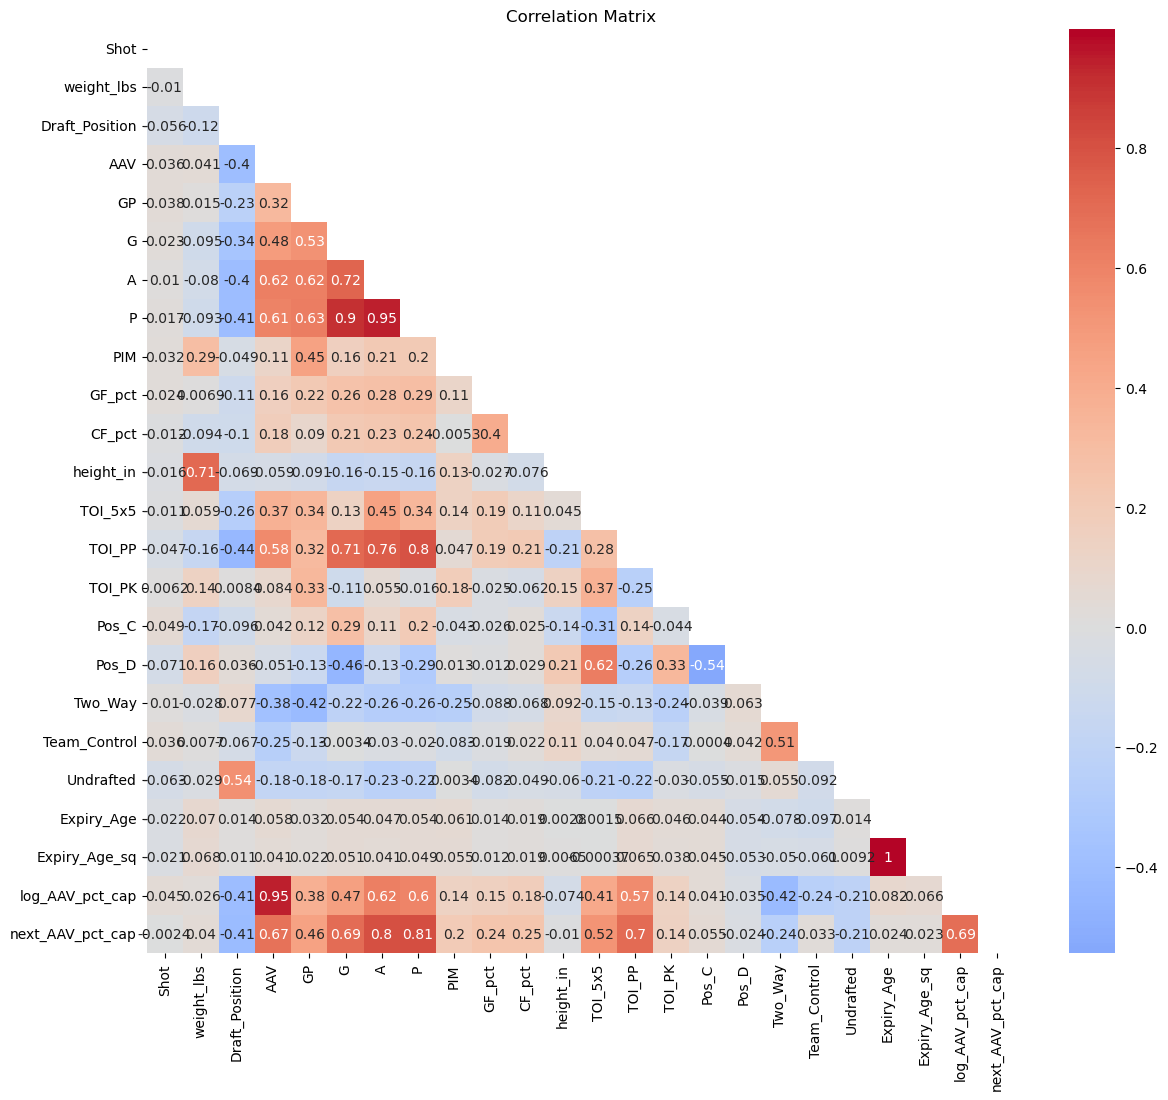

In [12]:
# Run correlation matrix to check for multicollinearity
numeric_df = contract_year_df[['Shot', 'weight_lbs', 'Draft_Position', 'AAV', 'GP', 'G', 'A', 'P', 'PIM', 'GF_pct', 'CF_pct', 'height_in', 'TOI_5x5', 'TOI_PP', 
                               'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Undrafted', 'Expiry_Age', 'Expiry_Age_sq', 'log_AAV_pct_cap','next_AAV_pct_cap']]
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

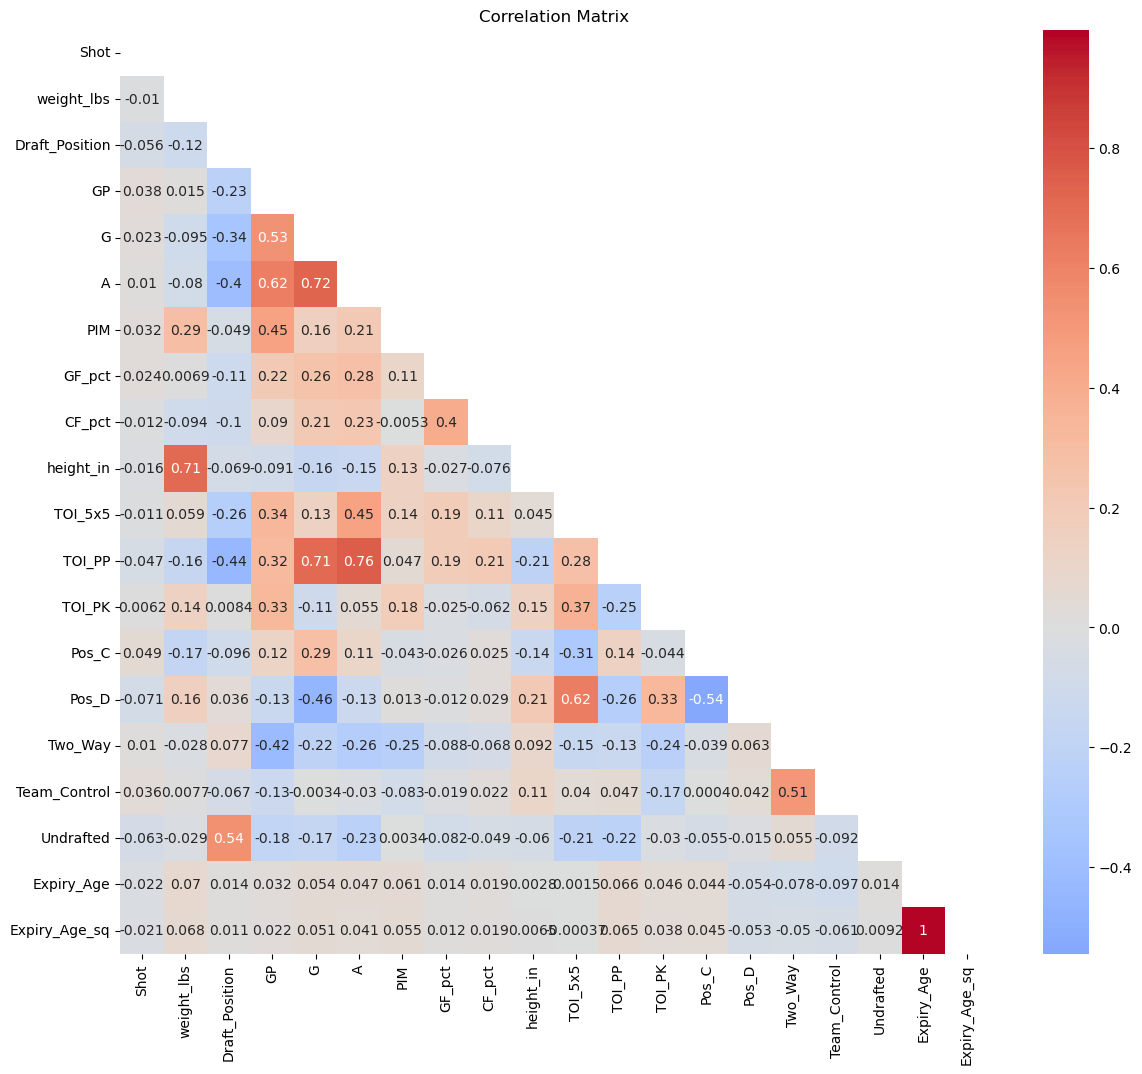

In [13]:
# Drop columns and re-check correlation
numeric_df = contract_year_df[['Shot', 'weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'GF_pct', 'CF_pct', 'height_in', 'TOI_5x5', 'TOI_PP', 
                               'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Undrafted', 'Expiry_Age', 'Expiry_Age_sq']]
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [14]:
# Feature selection
X1 = contract_year_df[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 'TOI_5x5', 'TOI_PP', 
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y1 = contract_year_df['next_AAV_pct_cap']

# Split data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=10)

Note: Shot, GF%, CF% were dropped after being found statistically insignificant in a refinement pass

## 1b) MLR Modeling (AAV) and Evaluation

### Modeling AAV

In [15]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train1, y_train1)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.0007393006717361511
Coefficients: [ 6.07976258e-05  5.42090891e-04 -2.56670057e-04  1.00345138e-03
  8.11317504e-04  7.32794384e-05  7.49522109e-04  1.82237574e-03
  3.42222576e-03  4.71003161e-03 -2.20229926e-03 -8.81220121e-04
 -2.99164818e-03  4.37749565e-03  2.87670847e-05 -2.34899072e-03
  8.81301545e-03]


### Evaluation

In [16]:
# Predictions
y_pred1 = model.predict(X_test1)

# Metrics
rmse1 = root_mean_squared_error(y_test1, y_pred1)
r2AAV = r2_score(y_test1, y_pred1)

print("Baseline Mean Squared Error:", rmse1)
print("Baseline R-Squared:", r2AAV)

Baseline Mean Squared Error: 0.011909201368343532
Baseline R-Squared: 0.8400242534371312


In [17]:
# Report the model significance
formula1 = 'next_AAV_pct_cap ~ weight_lbs + Draft_Position + GP + G + A + Expiry_Age + PIM + height_in + TOI_5x5 + TOI_PP + TOI_PK + Pos_C + Pos_D + Two_Way + Team_Control + Expiry_Age_sq + log_AAV_pct_cap'
train_data1 = pd.concat([X_train1, y_train1], axis=1)
model1 = smf.ols(formula=formula1, data=train_data1)
result1 = model1.fit()

In [18]:
print(result1.summary())

                            OLS Regression Results                            
Dep. Variable:       next_AAV_pct_cap   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     153.5
Date:                Tue, 05 May 2026   Prob (F-statistic):          1.60e-216
Time:                        19:01:08   Log-Likelihood:                 2018.1
No. Observations:                 681   AIC:                            -4000.
Df Residuals:                     663   BIC:                            -3919.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0007      0.025     

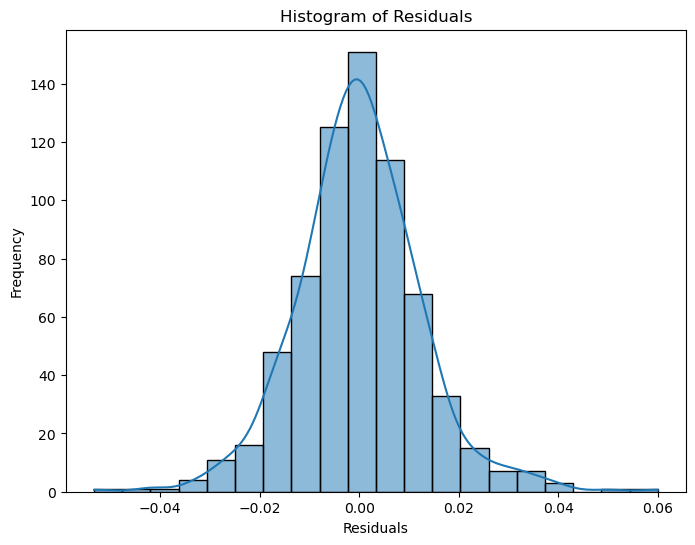

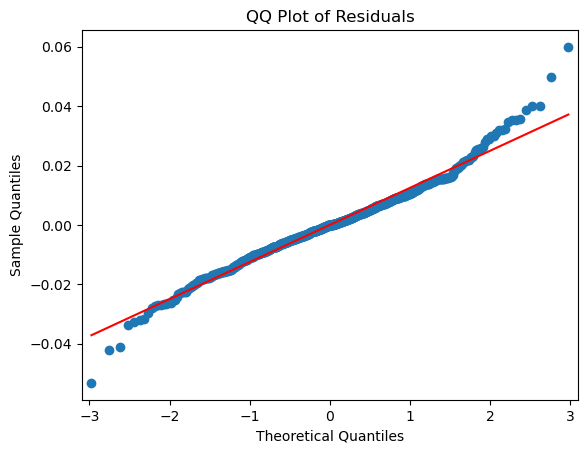

In [19]:
# Normality (Histogram & QQ-Plot)
X_train_sm1 = sm.add_constant(X_train1)
ols_model1 = sm.OLS(y_train1, X_train_sm1).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model1.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model1.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted AAV back to the dataframe.

In [20]:
X1_const_full = sm.add_constant(X1)
final_model1 = sm.OLS(y1, X1_const_full).fit()

In [21]:
contract_year_df['pred_AAV_pct_cap'] = final_model1.predict(X1_const_full)

In [22]:
contract_year_df[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.091438
1,Marner,0.123898,0.125654,0.118946
2,Benn,0.107955,0.041885,0.064300
3,Rantanen,0.105114,0.125654,0.112189
4,Crosby,0.098864,0.091099,0.100521


In [23]:
contract_year_df['pred_AAV'] = contract_year_df['pred_AAV_pct_cap'] * contract_year_df['Next_Cap_Ceiling']
contract_year_df[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,8.732345e+06
1,Marner,10903000,12000000.0,1.135933e+07
2,Benn,9500000,4000000.0,6.140648e+06
3,Rantanen,9250000,12000000.0,1.071402e+07
4,Crosby,8700000,8700000.0,9.599753e+06


## 1c) MLR Modeling (Length) and Evaluation

### Modeling Length

In [24]:
# Feature selection
X2 = contract_year_df[
    ['pred_AAV_pct_cap', 'Expiry_Age_sq', 'Expiry_Age', 'TOI_PP', 'TOI_PK']]
y2 = contract_year_df['next_length']

# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=10)

Note: G, A, TOI_5x5, Team_Control, Two_Way, Pos_C, and Pos_D were dropped 1) after being found statistically insignificant in a refinement pass or 2) due to redundancy with pred_AAV_pct_cap. 

In [25]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train2, y_train2)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.71128303526195
Coefficients: [ 6.04130187e+01  2.66220331e-03 -2.17552388e-01 -1.82382271e-01
  1.63716012e-01]


### Evaluation

In [26]:
# Predictions
y_pred2 = model.predict(X_test2)

# Metrics
rmse2 = root_mean_squared_error(y_test2, y_pred2)
r2Length = r2_score(y_test2, y_pred2)

print("Mean Squared Error:", rmse2)
print("R-Squared:", r2Length)

Mean Squared Error: 1.5447805161766617
R-Squared: 0.4970898219305777


In [27]:
# Report the model significance
formula2 = 'next_length ~ pred_AAV_pct_cap + Expiry_Age_sq + Expiry_Age + TOI_PP + TOI_PK'
train_data2 = pd.concat([X_train2, y_train2], axis=1)
model2 = smf.ols(formula=formula2, data=train_data2)
result2 = model2.fit()

In [28]:
print(result2.summary())

                            OLS Regression Results                            
Dep. Variable:            next_length   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     119.7
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.42e-90
Time:                        19:01:09   Log-Likelihood:                -1243.5
No. Observations:                 681   AIC:                             2499.
Df Residuals:                     675   BIC:                             2526.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.7113      1.290  

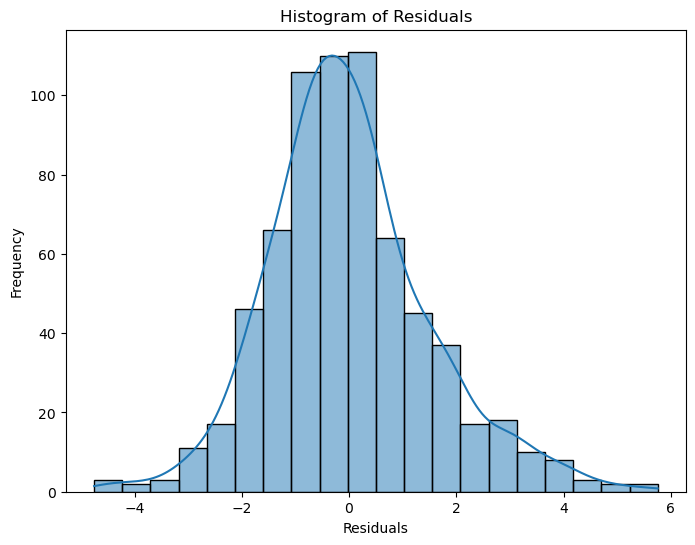

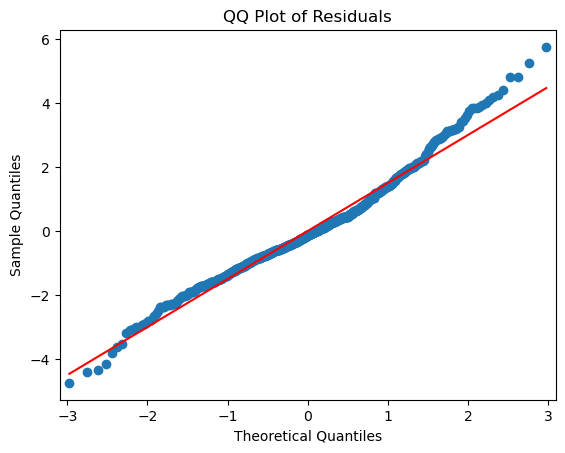

In [29]:
# Normality (Histogram & QQ-Plot)
X_train_sm2 = sm.add_constant(X_train2)
ols_model2 = sm.OLS(y_train2, X_train_sm2).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model2.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model2.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted length back to the dataframe.

In [30]:
X2_const_full = sm.add_constant(X2)
final_model2 = sm.OLS(y2, X2_const_full).fit()

In [31]:
contract_year_df['pred_length_raw'] = final_model2.predict(X2_const_full)
contract_year_df['pred_length'] = (contract_year_df['pred_length_raw'].round().clip(1, 8))

In [32]:
contract_year_df[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,5.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,4.0
3,Rantanen,6,8.0,7.0
4,Crosby,12,2.0,6.0


In [33]:
# Save baseline model results to csv file
contract_year_df.to_csv('baseline_model_results.csv', index=False)

# 2 - Model with Advanced Statistics

## 2a) EvolvingHockey Data Preprocessing

### Preprocess data for merging.

In [ ]:
# Read in data file.
initial_ehdf = pd.read_excel("../data/EvolvingHockeyData.xlsx")

In [35]:
# Remove unnecessary columns.
ehdf = initial_ehdf.drop(columns=["Off_GAR", "Def_GAR", "Pens_GAR", "GAR", "WAR", "SPAR"])
ehdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    3389 non-null   object 
 1   Season    3389 non-null   int64  
 2   Team      3389 non-null   object 
 3   Position  3389 non-null   object 
 4   GP        3389 non-null   int64  
 5   TOI_All   3389 non-null   float64
 6   EVO_GAR   3389 non-null   float64
 7   EVD_GAR   3389 non-null   float64
 8   PPO_GAR   3389 non-null   float64
 9   SHD_GAR   3389 non-null   float64
 10  Take_GAR  3389 non-null   float64
 11  Draw_GAR  3389 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 317.8+ KB


In [36]:
# Reformat Player into Last_Name and First_Name
ehdf['Player'] = ehdf['Player'].str.replace(r"\s*\(.*\)", "", regex=True)
ehdf[['First_Name', 'Last_Name']] = ehdf['Player'].str.split(' ', n=1, expand=True)
ehdf['First_Name'] = ehdf['First_Name'].str.strip()
ehdf['Last_Name'] = ehdf['Last_Name'].str.strip()

# Encode the position column
ehdf['Pos_C'] = (ehdf['Position'] == 'C').astype(int)
ehdf['Pos_D'] = (ehdf['Position'] == 'D').astype(int)

# Drop unnecessary columns
ehdf = ehdf.drop(columns=['Position', 'Player'])

In [37]:
ehdf.head(10)

,Season,Team,GP,TOI_All,EVO_GAR,EVD_GAR,PPO_GAR,SHD_GAR,Take_GAR,Draw_GAR,First_Name,Last_Name,Pos_C,Pos_D
0,2025,FLA,81,777.0,0.2,0.1,0.2,-0.6,-2.5,0.9,A.J.,Greer,0,0
1,2025,FLA,56,1316.7,2.5,-3.0,2.8,-0.6,-1.1,0.7,Aaron,Ekblad,0,1
2,2025,VAN,33,351.7,2.4,0.2,0.1,0.0,-0.6,0.3,Aatu,Raty,1,0
3,2025,FLA/NYI,35,492.5,1.5,-2.8,1.7,0.0,0.1,-0.3,Adam,Boqvist,0,1
4,2025,NYR,51,473.0,0.9,0.8,0.0,0.0,0.2,0.2,Adam,Edstrom,1,0
5,2025,CBJ,82,1433.2,6.0,-4.1,-2.3,0.4,1.3,1.0,Adam,Fantilli,1,0
6,2025,NYR,74,1720.4,11.3,3.5,1.5,-1.7,0.2,0.7,Adam,Fox,0,1
7,2025,OTT,81,844.2,6.7,1.7,-1.2,-0.1,0.7,-1.0,Adam,Gaudette,0,0
8,2025,EDM,81,1186.2,1.9,-1.7,0.0,0.3,1.3,-1.7,Adam,Henrique,1,0
9,2025,CGY,31,299.2,2.4,1.6,-0.1,0.0,-0.5,0.0,Adam,Klapka,0,0


### Merging and Sanity Check

The following cell was used to identified names which were spelled differently in the two databases used (PuckPedia and Evolving-Hockey). These names were retroactively fixed in section 1a, so the following cell has been marked as text. 

In [38]:
merged_df = contract_year_df.merge(
    ehdf,  
    on=['First_Name', 'Last_Name', 'Season'],
    how='left')

merged_df = merged_df.dropna()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 940 entries, 0 to 974
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Birthdate           940 non-null    datetime64[ns]
 1   Shot                940 non-null    int64         
 2   weight_lbs          940 non-null    int64         
 3   Draft_Position      940 non-null    float64       
 4   Length              940 non-null    int64         
 5   AAV                 940 non-null    int64         
 6   Expiry Status       940 non-null    object        
 7   GP_x                940 non-null    float64       
 8   G                   940 non-null    float64       
 9   A                   940 non-null    float64       
 10  P                   940 non-null    float64       
 11  PIM                 940 non-null    float64       
 12  GF_pct              940 non-null    float64       
 13  CF_pct              940 non-null    float64       
 14 

### Correlation Matrix and Feature Selection

In [39]:
# Drop unnecessary columns
merged_df = merged_df.drop(columns=['pred_AAV_pct_cap', 'pred_AAV', 'pred_length_raw','pred_length','TOI_All', 'Pos_C_y', 'Pos_D_y', 'GP_y'])

# Rename changed columns
merged_df = merged_df.rename(columns={'GP_x': 'GP', 'Pos_C_x': 'Pos_C', 'Pos_D_x': 'Pos_D'})

merged_df.columns

Index(['Birthdate', 'Shot', 'weight_lbs', 'Draft_Position', 'Length', 'AAV',
       'Expiry Status', 'GP', 'G', 'A', 'P', 'PIM', 'GF_pct', 'CF_pct',
       'Season', 'Next_Year', 'next_aav', 'next_length', 'Last_Name',
       'First_Name', 'height_in', 'TOI_5x5', 'TOI_PP', 'TOI_PK', 'Pos_C',
       'Pos_D', 'Two_Way', 'Team_Control', 'Undrafted', 'Expiry_Age',
       'Expiry_Age_sq', 'Draft_Position_Raw', 'Cap_Ceiling', 'AAV_pct_cap',
       'Next_Cap_Ceiling', 'next_AAV_pct_cap', 'log_AAV_pct_cap', 'Team',
       'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR'],
      dtype='object')

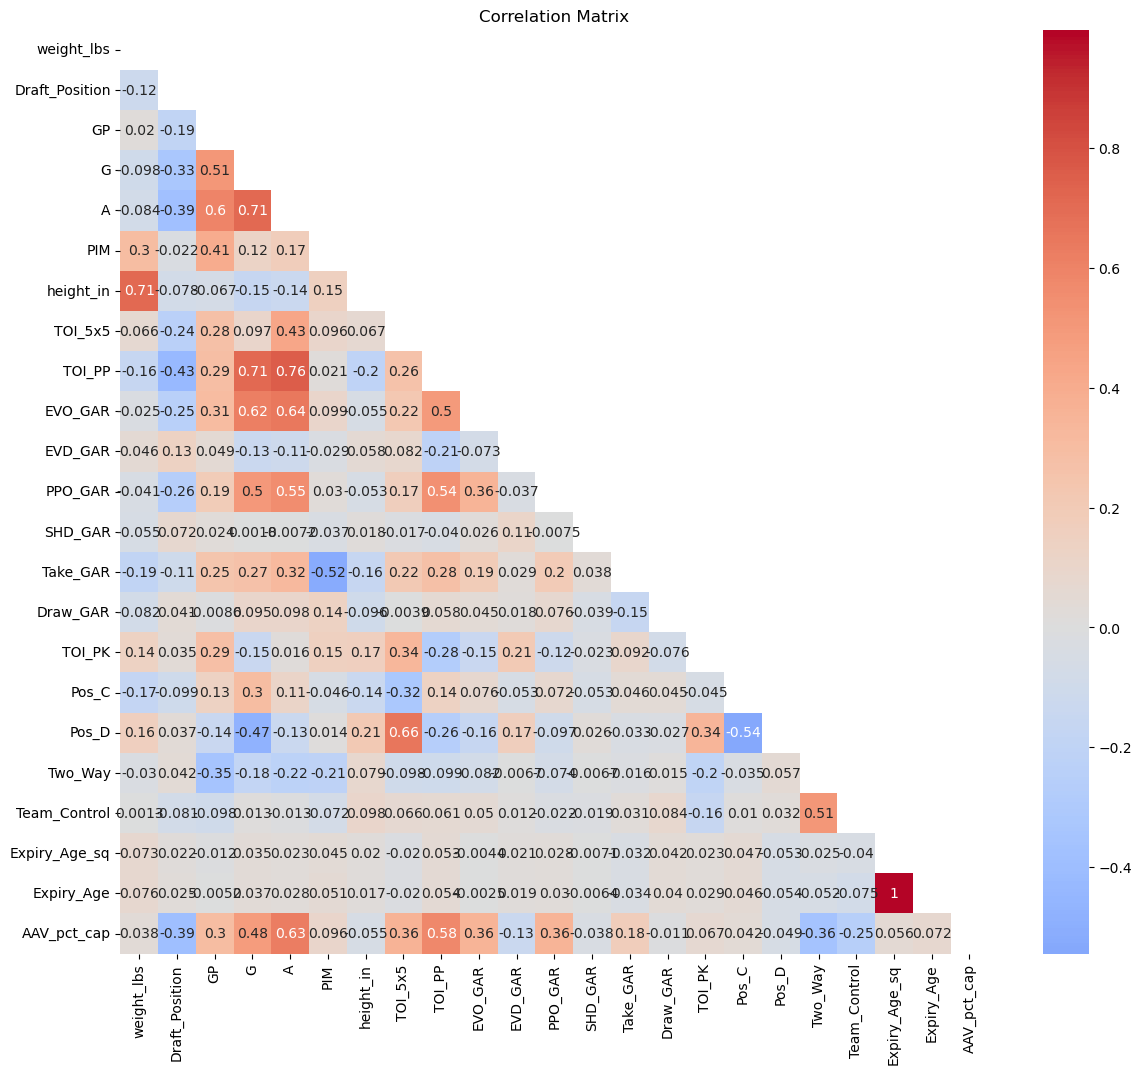

In [40]:
numeric_df = merged_df[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 'TOI_5x5', 'TOI_PP', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'AAV_pct_cap']]
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [41]:
# Feature selection
X3 = merged_df[['weight_lbs', 'Draft_Position', 'GP', 'PIM', 'height_in', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y3 = merged_df['next_AAV_pct_cap']

# Split data
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=10)

## 2b) MLR Modeling (AAV) and Evaluation

### Modeling AAV

In [42]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train3, y_train3)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.1210116085057286
Coefficients: [-7.26589247e-06 -7.17774187e-04  2.34567569e-05  2.36875346e-04
  6.92238147e-04  1.54042243e-03  1.78864310e-04  3.01979975e-03
  2.24787603e-04  6.92565084e-03  4.26447715e-03  2.15227529e-03
  2.04426202e-04  8.19179013e-04 -1.44718782e-03  6.51616567e-03
  5.15735357e-05 -4.15101778e-03  2.02984899e-02]


### Evaluation

In [43]:
# Predictions
y_pred3 = model.predict(X_test3)

# Metrics
rmse3 = root_mean_squared_error(y_test3, y_pred3)
r2AAVadv = r2_score(y_test3, y_pred3)

print("Mean Squared Error:", rmse3)
print("R-Squared:", r2AAVadv)

Mean Squared Error: 0.015175214996834354
R-Squared: 0.7204246256547554


In [44]:
# Report the model significance
formula3 = 'next_AAV_pct_cap ~ weight_lbs + Draft_Position + GP + Expiry_Age + PIM + height_in + Pos_C + Pos_D + Two_Way + Team_Control + Expiry_Age_sq + log_AAV_pct_cap + EVO_GAR + EVD_GAR + PPO_GAR +  SHD_GAR + Take_GAR + Draw_GAR'
train_data3 = pd.concat([X_train3, y_train3], axis=1)
model3 = smf.ols(formula=formula3, data=train_data3)
result3 = model3.fit()

In [45]:
print(result3.summary())

                            OLS Regression Results                            
Dep. Variable:       next_AAV_pct_cap   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     84.56
Date:                Tue, 05 May 2026   Prob (F-statistic):          1.56e-155
Time:                        19:01:14   Log-Likelihood:                 1805.8
No. Observations:                 658   AIC:                            -3574.
Df Residuals:                     639   BIC:                            -3488.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1132      0.031     

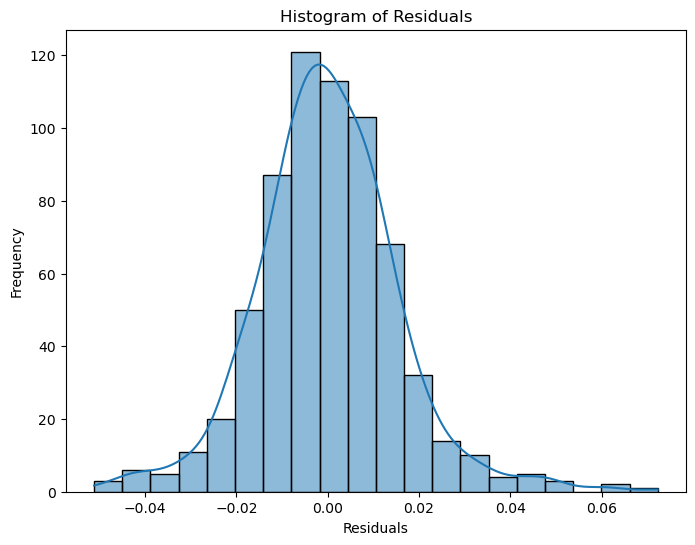

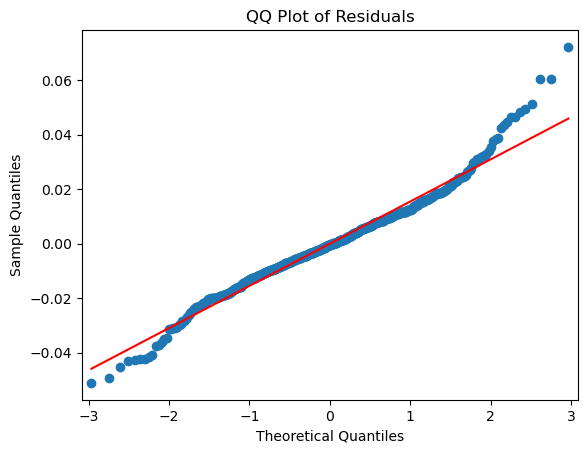

In [46]:
# Normality (Histogram & QQ-Plot)
X_train_sm3 = sm.add_constant(X_train3)
ols_model3 = sm.OLS(y_train3, X_train_sm3).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model3.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model3.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted AAV back to the dataframe.

In [47]:
X3_const_full = sm.add_constant(X3)
final_model3 = sm.OLS(y3, X3_const_full).fit()

In [48]:
merged_df['pred_AAV_pct_cap'] = final_model3.predict(X3_const_full)

In [49]:
merged_df[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.090407
1,Marner,0.123898,0.125654,0.111636
2,Benn,0.107955,0.041885,0.055729
3,Rantanen,0.105114,0.125654,0.051243
4,Crosby,0.098864,0.091099,0.086625


In [50]:
merged_df['pred_AAV'] = merged_df['pred_AAV_pct_cap'] * merged_df['Next_Cap_Ceiling']
merged_df[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,8.633857e+06
1,Marner,10903000,12000000.0,1.066120e+07
2,Benn,9500000,4000000.0,5.322164e+06
3,Rantanen,9250000,12000000.0,4.893713e+06
4,Crosby,8700000,8700000.0,8.272718e+06


## 2c) MLR Modeling (Length) and Evaluation

### Modeling Length

In [51]:
# Feature selection
X4 = merged_df[
    ['pred_AAV_pct_cap', 'Expiry_Age_sq', 'Expiry_Age', 'TOI_PP', 'TOI_PK', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR']]
y4 = merged_df['next_length']

# Split data
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.3, random_state=10)

Note: G, A, TOI_5x5, Team_Control, Two_Way, Pos_C, and Pos_D were dropped 1) after being found statistically insignificant in a refinement pass or 2) due to redundancy with pred_AAV_pct_cap. 

In [52]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train4, y_train4)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.9444643739901295
Coefficients: [ 4.53392474e+01  2.87450119e-03 -2.37135670e-01  3.52206664e-01
  3.89978364e-01  1.78643007e-02  5.88984024e-02 -6.26343240e-02
  5.47437938e-02 -9.64080493e-03  1.46948297e-01]


### Evaluation

In [53]:
# Predictions
y_pred4 = model.predict(X_test4)

# Metrics
rmse4 = root_mean_squared_error(y_test4, y_pred4)
r2Lengthadv = r2_score(y_test4, y_pred4)

print("Mean Squared Error:", rmse4)
print("R-Squared:", r2Lengthadv)

Mean Squared Error: 1.6357408995536478
R-Squared: 0.3972031257658507


In [54]:
# Report the model significance
formula4 = 'next_length ~ pred_AAV_pct_cap + Expiry_Age_sq + Expiry_Age + TOI_PP + TOI_PK'
train_data4 = pd.concat([X_train4, y_train4], axis=1)
model4 = smf.ols(formula=formula4, data=train_data4)
result4 = model4.fit()

In [55]:
print(result4.summary())

                            OLS Regression Results                            
Dep. Variable:            next_length   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     101.9
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.16e-79
Time:                        19:01:15   Log-Likelihood:                -1241.7
No. Observations:                 658   AIC:                             2495.
Df Residuals:                     652   BIC:                             2522.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            5.3321      1.461  

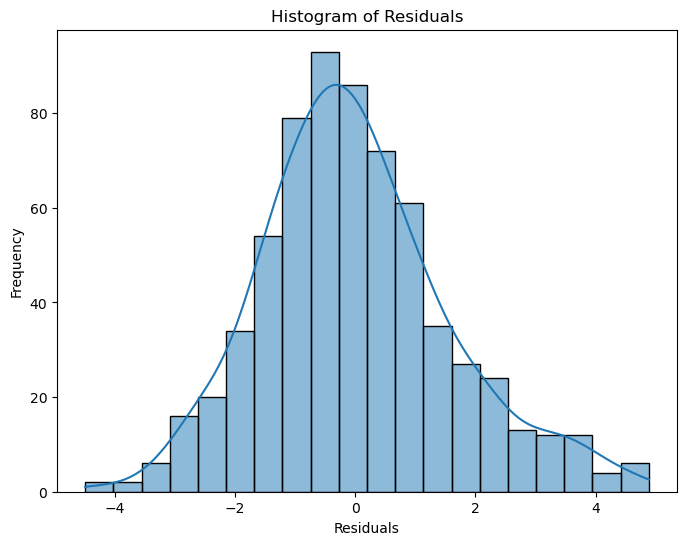

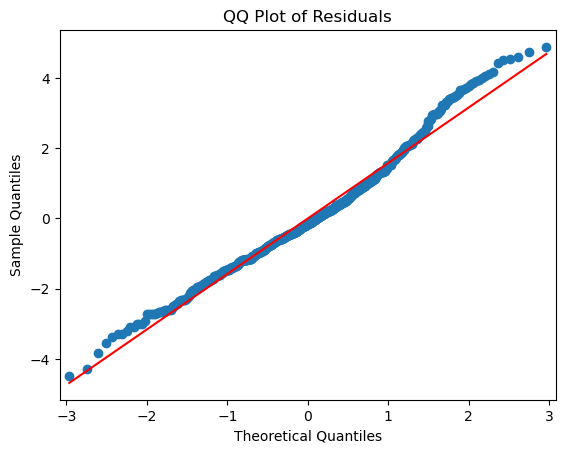

In [56]:
# Normality (Histogram & QQ-Plot)
X_train_sm4 = sm.add_constant(X_train4)
ols_model4 = sm.OLS(y_train4, X_train_sm4).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model4.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model4.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted length back to the dataframe.

In [57]:
X4_const_full = sm.add_constant(X4)
final_model4 = sm.OLS(y4, X4_const_full).fit()

In [58]:
merged_df['pred_length_raw'] = final_model4.predict(X4_const_full)
merged_df['pred_length'] = (merged_df['pred_length_raw'].round().clip(1, 8))

In [59]:
merged_df[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,5.0
1,Marner,6,8.0,7.0
2,Benn,8,1.0,4.0
3,Rantanen,6,8.0,4.0
4,Crosby,12,2.0,5.0


In [60]:
# Save advanced model results to csv file
merged_df.to_csv('gar_model_results.csv', index=False)

# 3 - Combination Model

## 3a) Feature Selection

In [61]:
# Make a copy of merged_df
combo_df = merged_df.copy()

# Feature selection
X5 = combo_df[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 'TOI_5x5', 'TOI_PP', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y5 = combo_df['next_AAV_pct_cap']

# Split data
X_train5, X_test5, y_train5, y_test5 = train_test_split(X5, y5, test_size=0.3, random_state=10)

## 3b) MLR Modeling (AAV) and Evaluation

### Modeling AAV

In [62]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train5, y_train5)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.021065182955904566
Coefficients: [ 7.28663552e-05  4.84250324e-04 -2.85202488e-04  1.04706153e-03
  7.71156156e-04  1.82014896e-04  8.82811291e-04  1.47893759e-03
  2.41510994e-03 -8.62427709e-05  4.74779164e-04 -3.96727639e-04
 -2.41580584e-04  4.58950185e-03  2.98023136e-03  3.57837947e-03
 -4.46783735e-04  1.01910537e-03 -2.58705690e-03  3.75026956e-03
  4.11203847e-05 -3.36057320e-03  1.15033702e-02]


### Evaluation

In [63]:
# Predictions
y_pred5 = model.predict(X_test5)

# Metrics
rmse5 = root_mean_squared_error(y_test5, y_pred5)
r2AAVcom = r2_score(y_test5, y_pred5)

print("Mean Squared Error:", rmse5)
print("R-Squared:", r2AAVcom)

Mean Squared Error: 0.01140150297388818
R-Squared: 0.8421831323016676


In [64]:
# Report the model significance
formula5 = 'next_AAV_pct_cap ~ weight_lbs + Draft_Position + GP + G + A + TOI_PP + TOI_5x5 + TOI_PK + Expiry_Age + PIM + height_in + Pos_C + Pos_D + Two_Way + Team_Control + Expiry_Age_sq + log_AAV_pct_cap + EVO_GAR + EVD_GAR + PPO_GAR +  SHD_GAR + Take_GAR + Draw_GAR'
train_data5 = pd.concat([X_train5, y_train5], axis=1)
model5 = smf.ols(formula=formula5, data=train_data5)
result5 = model5.fit()

In [65]:
print(result5.summary())

                            OLS Regression Results                            
Dep. Variable:       next_AAV_pct_cap   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     122.1
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.74e-215
Time:                        19:01:16   Log-Likelihood:                 1961.5
No. Observations:                 658   AIC:                            -3875.
Df Residuals:                     634   BIC:                            -3767.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0211      0.026     

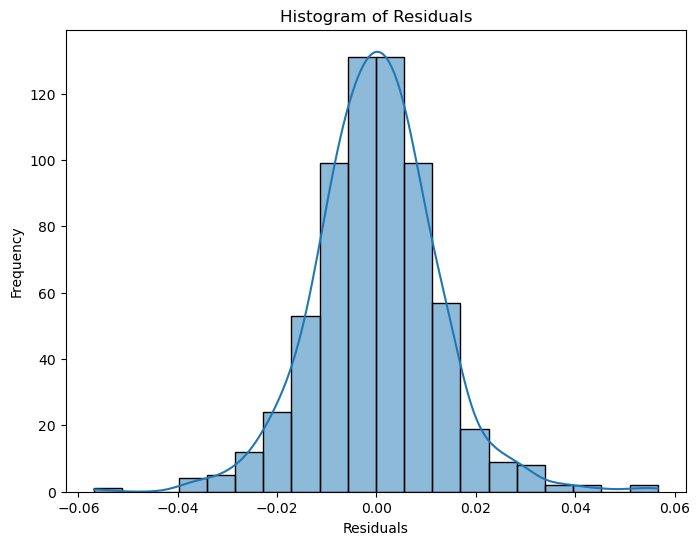

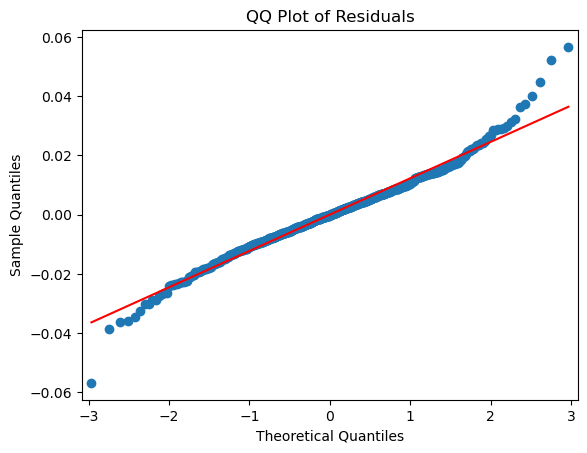

In [66]:
# Normality (Histogram & QQ-Plot)
X_train_sm5 = sm.add_constant(X_train5)
ols_model5 = sm.OLS(y_train5, X_train_sm5).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model5.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model5.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted AAV back to the dataframe. 

In [67]:
X5_const_full = sm.add_constant(X5)
final_model5 = sm.OLS(y5, X5_const_full).fit()

In [68]:
combo_df['pred_AAV_pct_cap'] = final_model5.predict(X5_const_full)

In [69]:
combo_df[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.085789
1,Marner,0.123898,0.125654,0.120498
2,Benn,0.107955,0.041885,0.057676
3,Rantanen,0.105114,0.125654,0.107023
4,Crosby,0.098864,0.091099,0.098504


In [70]:
combo_df['pred_AAV'] = combo_df['pred_AAV_pct_cap'] * combo_df['Next_Cap_Ceiling']
combo_df[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,8.192811e+06
1,Marner,10903000,12000000.0,1.150753e+07
2,Benn,9500000,4000000.0,5.508082e+06
3,Rantanen,9250000,12000000.0,1.022071e+07
4,Crosby,8700000,8700000.0,9.407102e+06


## 3c) MLR Modeling (Length) and Evaluation

### Modeling Length

In [71]:
# Feature selection
X6 = combo_df[
    ['pred_AAV_pct_cap', 'Expiry_Age_sq', 'Expiry_Age', 'TOI_PP', 'TOI_PK']]
y6 = combo_df['next_length']

# Split data
X_train6, X_test6, y_train6, y_test6 = train_test_split(X6, y6, test_size=0.3, random_state=10)

Note: G, A, TOI_5x5, Team_Control, Two_Way, Pos_C, and Pos_D were dropped 1) after being found statistically insignificant in a refinement pass or 2) due to redundancy with pred_AAV_pct_cap. 

In [72]:
# Modeling
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train6, y_train6)

# Get model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.621389157333408
Coefficients: [ 7.07106204e+01  2.57022952e-03 -2.09458784e-01 -3.98374091e-01
  3.37857310e-02]


### Evaluation

In [73]:
# Predictions
y_pred6 = model.predict(X_test6)

# Metrics
rmse6 = root_mean_squared_error(y_test6, y_pred6)
r2Lengthcom = r2_score(y_test6, y_pred6)

print("Mean Squared Error:", rmse6)
print("R-Squared:", r2Lengthcom)

Mean Squared Error: 1.5685858499717218
R-Squared: 0.44568254800684304


In [74]:
# Report the model significance
formula6 = 'next_length ~ pred_AAV_pct_cap + Expiry_Age_sq + Expiry_Age + TOI_PP + TOI_PK'
train_data6 = pd.concat([X_train6, y_train6], axis=1)
model6 = smf.ols(formula=formula6, data=train_data6)
result6 = model6.fit()

In [75]:
print(result6.summary())

                            OLS Regression Results                            
Dep. Variable:            next_length   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     139.3
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.17e-100
Time:                        19:01:16   Log-Likelihood:                -1192.6
No. Observations:                 658   AIC:                             2397.
Df Residuals:                     652   BIC:                             2424.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.6214      1.358  

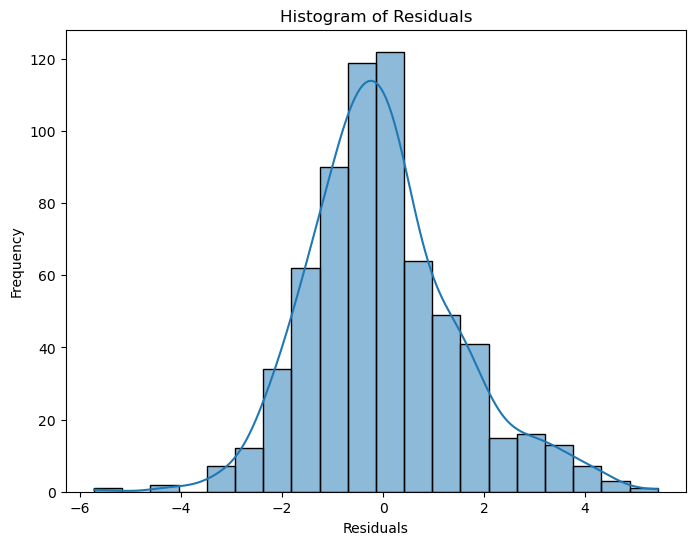

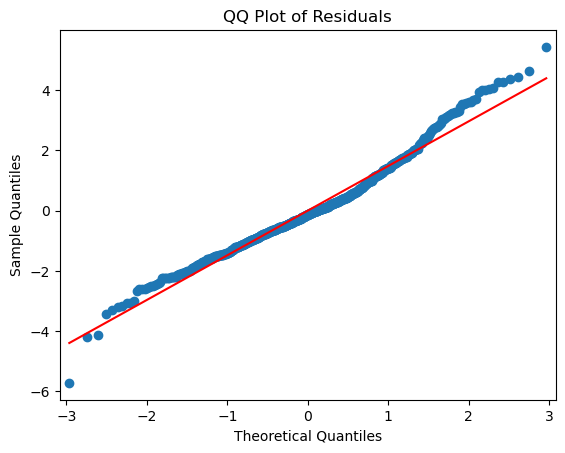

In [76]:
# Normality (Histogram & QQ-Plot)
X_train_sm6 = sm.add_constant(X_train6)
ols_model6 = sm.OLS(y_train6, X_train_sm6).fit()

plt.figure(figsize=(8, 6))
sns.histplot(ols_model6.resid, kde=True, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

sm.qqplot(ols_model6.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Assigning the model's predicted length back to the dataframe. 

In [77]:
X6_const_full = sm.add_constant(X6)
final_model6 = sm.OLS(y6, X6_const_full).fit()

In [78]:
combo_df['pred_length_raw'] = final_model6.predict(X6_const_full)
combo_df['pred_length'] = (combo_df['pred_length_raw'].round().clip(1, 8))

In [79]:
combo_df[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,5.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,4.0
3,Rantanen,6,8.0,7.0
4,Crosby,12,2.0,6.0


In [80]:
# Save combination model results to csv file
combo_df.to_csv('combo_model_results.csv', index=False)

# 4 - Random Forest Model (GAR)

## 4a) Feature Selection

In [81]:
# Make a copy of merged_df
ml_df = merged_df.copy()

# Feature selection
X7 = ml_df[['weight_lbs', 'Draft_Position', 'GP', 'PIM', 'height_in', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y7 = ml_df['next_AAV_pct_cap']

# Split data
X_train7, X_test7, y_train7, y_test7 = train_test_split(X7, y7, test_size=0.3, random_state=10)

## 4b) ML Modeling (AAV) and Evaluation

### Modeling AAV

In [82]:
# Train a Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,     
    max_depth=6,       
    min_samples_split=5,
    random_state=10       
)
rf.fit(X_train7, y_train7)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Evaluation

In [83]:
# Evaluate the model
y_pred7 = rf.predict(X_test7)

# Metrics
rmse7 = root_mean_squared_error(y_test7, y_pred7)
r2AAVrf = r2_score(y_test7, y_pred7)

print("Mean Squared Error:", rmse7)
print("R-Squared:", r2AAVrf)

Mean Squared Error: 0.015535154693008531
R-Squared: 0.7070048888011977


In [84]:
# Feature Importance
feature_importances = rf.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X7.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
weight_lbs: 0.0109
Draft_Position: 0.0295
GP: 0.0453
PIM: 0.0198
height_in: 0.0064
EVO_GAR: 0.1336
EVD_GAR: 0.0147
PPO_GAR: 0.1161
SHD_GAR: 0.0108
Take_GAR: 0.0206
Draw_GAR: 0.0224
TOI_PK: 0.0191
Pos_C: 0.0010
Pos_D: 0.0009
Two_Way: 0.0010
Team_Control: 0.0193
Expiry_Age_sq: 0.0116
Expiry_Age: 0.0108
log_AAV_pct_cap: 0.5062


### Assigning the model's predicted AAV back to the dataframe.

In [85]:
# Refit RF on full dataset
rf.fit(X7, y7)

# Store predictions for all rows
ml_df['pred_AAV_pct_cap'] = rf.predict(X7)

In [86]:
ml_df[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.073413
1,Marner,0.123898,0.125654,0.107649
2,Benn,0.107955,0.041885,0.056225
3,Rantanen,0.105114,0.125654,0.088388
4,Crosby,0.098864,0.091099,0.089810


In [87]:
ml_df['pred_AAV'] = ml_df['pred_AAV_pct_cap'] * ml_df['Next_Cap_Ceiling']
ml_df[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,7.010934e+06
1,Marner,10903000,12000000.0,1.028050e+07
2,Benn,9500000,4000000.0,5.369511e+06
3,Rantanen,9250000,12000000.0,8.441067e+06
4,Crosby,8700000,8700000.0,8.576869e+06


## 4c) ML Modeling (Length) and Evaluation

### Feature Re-selection

In [88]:
# Re-select features 
X8 = ml_df[['pred_AAV_pct_cap', 'Expiry_Age', 'Expiry_Age_sq', 'TOI_PP', 'TOI_PK']]

y8 = ml_df['next_length']

# Split data
X_train8, X_test8, y_train8, y_test8 = train_test_split(X8, y8, test_size=0.3, random_state=10)

### Modeling Length

In [89]:
rf2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=10
)

rf2.fit(X_train8, y_train8)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Evaluation

In [90]:
# Evaluate the model
y_pred8 = rf2.predict(X_test8)

# Metrics
rmse8 = root_mean_squared_error(y_test8, y_pred8)
r2AAVrf2 = r2_score(y_test8, y_pred8)

print("Mean Squared Error:", rmse8)
print("R-Squared:", r2AAVrf2)

Mean Squared Error: 1.5026857818220365
R-Squared: 0.49128057571518113


In [91]:
# Feature Importance
feature_importances = rf2.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X8.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
pred_AAV_pct_cap: 0.7715
Expiry_Age: 0.0384
Expiry_Age_sq: 0.0386
TOI_PP: 0.0754
TOI_PK: 0.0761


### Assigning the model's predicted length back to the dataframe.

In [92]:
# Refit RF on full dataset
rf2.fit(X8, y8)

# Store predictions for all rows
ml_df['pred_length_raw'] = rf2.predict(X8)
ml_df['pred_length'] = (ml_df['pred_length_raw'].round().clip(1, 8))

In [93]:
ml_df[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,4.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,3.0
3,Rantanen,6,8.0,7.0
4,Crosby,12,2.0,4.0


In [94]:
# Save random forest model results to csv file
ml_df.to_csv('rf_gar_model_results.csv', index=False)

# 5 - Random Forest Model (Combination)

## 5a) Feature Selection

In [95]:
# Make a copy of merged_df
rf_df = merged_df.copy()

# Feature selection
X9 = rf_df[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 'TOI_5x5', 'TOI_PP', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y9 = rf_df['next_AAV_pct_cap']

# Split data
X_train9, X_test9, y_train9, y_test9 = train_test_split(X9, y9, test_size=0.3, random_state=10)

## 5b) ML Modeling (AAV) and Evaluation

### Modeling AAV

In [96]:
# Train a Random Forest Regressor
rf3 = RandomForestRegressor(
    n_estimators=100,     
    max_depth=6,       
    min_samples_split=5,
    random_state=10       
)
rf3.fit(X_train9, y_train9)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Evaluation

In [97]:
# Evaluate the model
y_pred9 = rf3.predict(X_test9)

# Metrics
rmse9 = root_mean_squared_error(y_test9, y_pred9)
r2AAVrf3 = r2_score(y_test9, y_pred9)

print("Mean Squared Error:", rmse9)
print("R-Squared:", r2AAVrf3)

Mean Squared Error: 0.011826521559708671
R-Squared: 0.8301978185458413


In [98]:
# Feature Importance
feature_importances = rf3.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X9.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
weight_lbs: 0.0064
Draft_Position: 0.0085
GP: 0.0089
G: 0.0595
A: 0.5689
PIM: 0.0079
height_in: 0.0083
TOI_5x5: 0.0624
TOI_PP: 0.0444
EVO_GAR: 0.0166
EVD_GAR: 0.0073
PPO_GAR: 0.0099
SHD_GAR: 0.0050
Take_GAR: 0.0056
Draw_GAR: 0.0076
TOI_PK: 0.0098
Pos_C: 0.0003
Pos_D: 0.0000
Two_Way: 0.0005
Team_Control: 0.0028
Expiry_Age_sq: 0.0036
Expiry_Age: 0.0038
log_AAV_pct_cap: 0.1520


### Assigning the model's predicted AAV back to the dataframe.

In [99]:
# Refit RF on full dataset
rf3.fit(X9, y9)

# Store predictions for all rows
rf_df['pred_AAV_pct_cap'] = rf3.predict(X9)

In [100]:
rf_df[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.069862
1,Marner,0.123898,0.125654,0.107659
2,Benn,0.107955,0.041885,0.050767
3,Rantanen,0.105114,0.125654,0.112964
4,Crosby,0.098864,0.091099,0.101890


In [101]:
rf_df['pred_AAV'] = rf_df['pred_AAV_pct_cap'] * rf_df['Next_Cap_Ceiling']
rf_df[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,6.671774e+06
1,Marner,10903000,12000000.0,1.028141e+07
2,Benn,9500000,4000000.0,4.848233e+06
3,Rantanen,9250000,12000000.0,1.078809e+07
4,Crosby,8700000,8700000.0,9.730509e+06


## 5c) ML Modeling (Length) and Evaluation

### Feature Re-selection

In [102]:
# Re-select features 
X10 = rf_df[['pred_AAV_pct_cap', 'Expiry_Age', 'Expiry_Age_sq', 'TOI_PP', 'TOI_PK']]

y10 = rf_df['next_length']

# Split data
X_train10, X_test10, y_train10, y_test10 = train_test_split(X10, y10, test_size=0.3, random_state=10)

### Modeling Length

In [103]:
rf4 = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=10
)

rf4.fit(X_train10, y_train10)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Evaluation

In [104]:
# Evaluate the model
y_pred10 = rf4.predict(X_test10)

# Metrics
rmse10 = root_mean_squared_error(y_test10, y_pred10)
r2AAVrf4 = r2_score(y_test10, y_pred10)

print("Mean Squared Error:", rmse10)
print("R-Squared:", r2AAVrf4)

Mean Squared Error: 1.4818810273682332
R-Squared: 0.5052695497956569


In [105]:
# Feature Importance
feature_importances = rf4.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X10.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
pred_AAV_pct_cap: 0.7786
Expiry_Age: 0.0296
Expiry_Age_sq: 0.0285
TOI_PP: 0.0927
TOI_PK: 0.0706


### Assigning the model's predicted length back to the dataframe.

In [106]:
# Refit RF on full dataset
rf4.fit(X10, y10)

# Store predictions for all rows
rf_df['pred_length_raw'] = rf4.predict(X10)
rf_df['pred_length'] = (rf_df['pred_length_raw'].round().clip(1, 8))

In [107]:
rf_df[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,3.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,2.0
3,Rantanen,6,8.0,7.0
4,Crosby,12,2.0,4.0


In [108]:
# Save random forest model results to csv file
rf_df.to_csv('rf_combo_model_results.csv', index=False)

# 6 - XGBoost Model (GAR)

## 6a) Feature Selection

In [109]:
# Make a copy of merged_df
xgb_df1 = merged_df.copy()

# Feature selection
X11 = xgb_df1[['weight_lbs', 'Draft_Position', 'GP', 'PIM', 'height_in', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y11 = xgb_df1['next_AAV_pct_cap']

# Split data
X_train11, X_test11, y_train11, y_test11 = train_test_split(X11, y11, test_size=0.3, random_state=10)

## 6b) XGB Modeling (AAV) and Evaluation

### Modeling AAV

In [110]:
# Train XGBoost regressor
xgb1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=10
)

xgb1.fit(X_train11, y_train11)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Evaluation

In [111]:
# Predict on test set
y_pred11 = xgb1.predict(X_test11)

# Evaluate
rmse11 = root_mean_squared_error(y_test11, y_pred11)
r2_11 = r2_score(y_test11, y_pred11)

print("Mean Squared Error:", rmse11)
print("R-Squared:", r2_11)

Mean Squared Error: 0.014514497712939091
R-Squared: 0.7442396413815529


In [112]:
# Feature importances
xgb1_importance = pd.DataFrame({
    'Feature': X11.columns,
    'Importance': xgb1.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
for _, row in xgb1_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Feature Importances:
log_AAV_pct_cap: 0.2353
Team_Control: 0.1601
PPO_GAR: 0.0937
EVO_GAR: 0.0902
Expiry_Age: 0.0625
GP: 0.0458
Take_GAR: 0.0370
Expiry_Age_sq: 0.0333
Draft_Position: 0.0321
PIM: 0.0300
Draw_GAR: 0.0299
TOI_PK: 0.0264
EVD_GAR: 0.0212
Pos_D: 0.0209
height_in: 0.0195
Pos_C: 0.0181
SHD_GAR: 0.0166
Two_Way: 0.0151
weight_lbs: 0.0122


### Assigning the model's predicted AAV back to the dataframe.

In [113]:
# Refit RF on full dataset
xgb1.fit(X11, y11)

# Store predictions for all rows
xgb_df1['pred_AAV_pct_cap'] = xgb1.predict(X11)

In [114]:
xgb_df1[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.046468
1,Marner,0.123898,0.125654,0.124974
2,Benn,0.107955,0.041885,0.042765
3,Rantanen,0.105114,0.125654,0.123015
4,Crosby,0.098864,0.091099,0.089914


In [115]:
xgb_df1['pred_AAV'] = xgb_df1['pred_AAV_pct_cap'] * xgb_df1['Next_Cap_Ceiling']
xgb_df1[['Last_Name', 'AAV', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_aav,pred_AAV
0,Tavares,11000000,4389280.0,4.437665e+06
1,Marner,10903000,12000000.0,1.193504e+07
2,Benn,9500000,4000000.0,4.084097e+06
3,Rantanen,9250000,12000000.0,1.174795e+07
4,Crosby,8700000,8700000.0,8.586801e+06


## 6c) XGB Modeling (Length) and Evaluation

### Feature Re-selection

In [116]:
# Re-select features 
X12 = xgb_df1[['pred_AAV_pct_cap', 'Expiry_Age', 'Expiry_Age_sq', 'TOI_PP', 'TOI_PK']]

y12 = xgb_df1['next_length']

# Split data
X_train12, X_test12, y_train12, y_test12 = train_test_split(X12, y12, test_size=0.3, random_state=10)

### Modeling Length

In [117]:
# Train XGBoost regressor for length
xgb2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=10
)

xgb2.fit(X_train12, y_train12)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Evaluation

In [118]:
# Predict on test set
y_pred12 = xgb2.predict(X_test12)

# Evaluate
rmse12 = root_mean_squared_error(y_test12, y_pred12)
r2_12 = r2_score(y_test12, y_pred12)

print("Mean Squared Error:", rmse12)
print("R-Squared:", r2_12)

Mean Squared Error: 1.3916830270783442
R-Squared: 0.5636624112518801


In [119]:
# Feature importances
xgb2_importance = pd.DataFrame({
    'Feature': X12.columns,
    'Importance': xgb2.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
for _, row in xgb2_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Feature Importances:
pred_AAV_pct_cap: 0.5173
TOI_PP: 0.1573
TOI_PK: 0.1167
Expiry_Age_sq: 0.1128
Expiry_Age: 0.0958


### Assigning the model's predicted length back to the dataframe.

In [120]:
# Refit RF on full dataset
xgb2.fit(X10, y10)

# Store predictions for all rows
xgb_df1['pred_length_raw'] = xgb2.predict(X10)
xgb_df1['pred_length'] = (xgb_df1['pred_length_raw'].round().clip(1, 8))

In [121]:
xgb_df1[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,4.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,1.0
3,Rantanen,6,8.0,8.0
4,Crosby,12,2.0,3.0


In [122]:
# Save XGBoost model results to csv file
xgb_df1.to_csv('xgb_gar_model_results.csv', index=False)

# 7 - XGBoost Model (Combination)

## 7a) Feature Selection

In [123]:
# Make a copy of merged_df
xgb_df2 = merged_df.copy()

# Feature selection
X13 = xgb_df2[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 'TOI_5x5', 'TOI_PP', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR',
                    'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'log_AAV_pct_cap']]
y13 = xgb_df2['next_AAV_pct_cap']

# Split data
X_train13, X_test13, y_train13, y_test13 = train_test_split(X13, y13, test_size=0.3, random_state=10)

## 7b) XGB Modeling (AAV) and Evaluation

### Modeling AAV

In [124]:
# Train XGBoost regressor
xgb3 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=10
)

xgb3.fit(X_train13, y_train13)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Evaluation

In [125]:
# Predict on test set
y_pred13 = xgb3.predict(X_test13)

# Evaluate
rmse13 = root_mean_squared_error(y_test13, y_pred13)
r2_13 = r2_score(y_test13, y_pred13)

print("Mean Squared Error:", rmse13)
print("R-Squared:", r2_13)

Mean Squared Error: 0.011051893874507484
R-Squared: 0.8517131561965781


In [126]:
# Feature importances
xgb3_importance = pd.DataFrame({
    'Feature': X13.columns,
    'Importance': xgb3.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
for _, row in xgb3_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Feature Importances:
A: 0.3810
TOI_PP: 0.1452
log_AAV_pct_cap: 0.1017
TOI_5x5: 0.0633
G: 0.0606
Team_Control: 0.0314
TOI_PK: 0.0189
height_in: 0.0173
Pos_D: 0.0167
EVD_GAR: 0.0166
Draw_GAR: 0.0163
EVO_GAR: 0.0161
Expiry_Age_sq: 0.0135
Expiry_Age: 0.0129
GP: 0.0123
Two_Way: 0.0120
PPO_GAR: 0.0120
Draft_Position: 0.0114
PIM: 0.0113
weight_lbs: 0.0108
Take_GAR: 0.0087
SHD_GAR: 0.0073
Pos_C: 0.0028


### Assigning the model's predicted AAV back to the dataframe.

In [127]:
# Refit RF on full dataset
xgb3.fit(X13, y13)

# Store predictions for all rows
xgb_df2['pred_AAV_pct_cap'] = xgb3.predict(X13)

In [128]:
xgb_df2[['Last_Name', 'AAV_pct_cap', 'next_AAV_pct_cap', 'pred_AAV_pct_cap']].head()

,Last_Name,AAV_pct_cap,next_AAV_pct_cap,pred_AAV_pct_cap
0,Tavares,0.125000,0.045961,0.046210
1,Marner,0.123898,0.125654,0.124838
2,Benn,0.107955,0.041885,0.041744
3,Rantanen,0.105114,0.125654,0.123940
4,Crosby,0.098864,0.091099,0.092561


In [129]:
xgb_df2['pred_AAV'] = xgb_df2['pred_AAV_pct_cap'] * xgb_df2['Next_Cap_Ceiling']
xgb_df2[['Last_Name', 'AAV', 'next_AAV_pct_cap', 'Next_Cap_Ceiling', 'next_aav', 'pred_AAV']].head()

,Last_Name,AAV,next_AAV_pct_cap,Next_Cap_Ceiling,next_aav,pred_AAV
0,Tavares,11000000,0.045961,95500000,4389280.0,4.413020e+06
1,Marner,10903000,0.125654,95500000,12000000.0,1.192205e+07
2,Benn,9500000,0.041885,95500000,4000000.0,3.986579e+06
3,Rantanen,9250000,0.125654,95500000,12000000.0,1.183627e+07
4,Crosby,8700000,0.091099,95500000,8700000.0,8.839560e+06


## 7c) XGB Modeling (Length) and Evaluation

### Feature Re-selection

In [130]:
# Re-select features 
X14 = xgb_df2[['pred_AAV_pct_cap', 'Expiry_Age', 'Expiry_Age_sq', 'TOI_PP', 'TOI_PK']]

y14 = xgb_df2['next_length']

# Split data
X_train14, X_test14, y_train14, y_test14 = train_test_split(X14, y14, test_size=0.3, random_state=10)

### Modeling Length

In [131]:
# Train XGBoost regressor for length
xgb4 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=10
)

xgb4.fit(X_train14, y_train14)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Evaluation

In [132]:
# Predict on test set
y_pred14 = xgb4.predict(X_test14)

# Evaluate
rmse14 = root_mean_squared_error(y_test14, y_pred14)
r2_14 = r2_score(y_test14, y_pred14)

print("Mean Squared Error:", rmse14)
print("R-Squared:", r2_14)

Mean Squared Error: 1.4319682946353425
R-Squared: 0.5380353217684268


In [133]:
# Feature importances
xgb4_importance = pd.DataFrame({
    'Feature': X14.columns,
    'Importance': xgb4.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
for _, row in xgb4_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Feature Importances:
pred_AAV_pct_cap: 0.5272
TOI_PP: 0.1509
TOI_PK: 0.1153
Expiry_Age_sq: 0.1126
Expiry_Age: 0.0940


### Assigning the model's predicted length back to the dataframe.

In [134]:
# Refit RF on full dataset
xgb4.fit(X10, y10)

# Store predictions for all rows
xgb_df2['pred_length_raw'] = xgb4.predict(X10)
xgb_df2['pred_length'] = (xgb_df2['pred_length_raw'].round().clip(1, 8))

In [135]:
xgb_df2[['Last_Name', 'Length', 'next_length', 'pred_length']].head()

,Last_Name,Length,next_length,pred_length
0,Tavares,7,4.0,4.0
1,Marner,6,8.0,8.0
2,Benn,8,1.0,1.0
3,Rantanen,6,8.0,8.0
4,Crosby,12,2.0,3.0


In [136]:
# Save XGBoost model results to csv file
xgb_df2.to_csv('xgb_combo_model_results.csv', index=False)

# 8 - Results and Figure Creation

## Results

In [137]:
print("Baseline AAV Mean Squared Error:", rmse1)
print("Baseline AAV R-Squared:", r2AAV)
print("Baseline Length Mean Squared Error:", rmse2)
print("Baseline Length R-Squared:", r2Length)

print('='*80)

print("Advanced AAV Mean Squared Error:", rmse3)
print("Advanced AAV R-Squared:", r2AAVadv)
print("Advanced Length Mean Squared Error:", rmse4)
print("Advanced Length R-Squared:", r2Lengthadv)

print('='*80)

print("Combination AAV Mean Squared Error:", rmse5)
print("Combination AAV R-Squared:", r2AAVcom)
print("Combination Length Mean Squared Error:", rmse6)
print("Combination Length R-Squared:", r2Lengthcom)

print('='*80)

print("Random Forest Advanced AAV Mean Squared Error:", rmse7)
print("Random Forest Advanced AAV R-Squared:", r2AAVrf)
print("Random Forest Advanced Length Mean Squared Error:", rmse8)
print("Random Forest Advanced Length R-Squared:", r2AAVrf2)

print('='*80)

print("Random Forest Combination AAV Mean Squared Error:", rmse9)
print("Random Forest Combination AAV R-Squared:", r2AAVrf3)
print("Random Forest Combination Length Mean Squared Error:", rmse10)
print("Random Forest Combination Length R-Squared:", r2AAVrf4)

print('='*80)

print("XGBoost Advanced AAV Mean Squared Error:", rmse11)
print("XGBoost Advanced AAV R-Squared:", r2_11)
print("XGBoost Advanced Length Mean Squared Error:", rmse12)
print("XGBoost Advanced Length R-Squared:", r2_12)

print('='*80)

print("XGBoost Combination AAV Mean Squared Error:", rmse13)
print("XGBoost Combination AAV R-Squared:", r2_13)
print("XGBoost Combination Length Mean Squared Error:", rmse14)
print("XGBoost Combination Length R-Squared:", r2_14)

Baseline AAV Mean Squared Error: 0.011909201368343532
Baseline AAV R-Squared: 0.8400242534371312
Baseline Length Mean Squared Error: 1.5447805161766617
Baseline Length R-Squared: 0.4970898219305777
Advanced AAV Mean Squared Error: 0.015175214996834354
Advanced AAV R-Squared: 0.7204246256547554
Advanced Length Mean Squared Error: 1.6357408995536478
Advanced Length R-Squared: 0.3972031257658507
Combination AAV Mean Squared Error: 0.01140150297388818
Combination AAV R-Squared: 0.8421831323016676
Combination Length Mean Squared Error: 1.5685858499717218
Combination Length R-Squared: 0.44568254800684304
Random Forest Advanced AAV Mean Squared Error: 0.015535154693008531
Random Forest Advanced AAV R-Squared: 0.7070048888011977
Random Forest Advanced Length Mean Squared Error: 1.5026857818220365
Random Forest Advanced Length R-Squared: 0.49128057571518113
Random Forest Combination AAV Mean Squared Error: 0.011826521559708671
Random Forest Combination AAV R-Squared: 0.8301978185458413
Random F

## Figure Creation

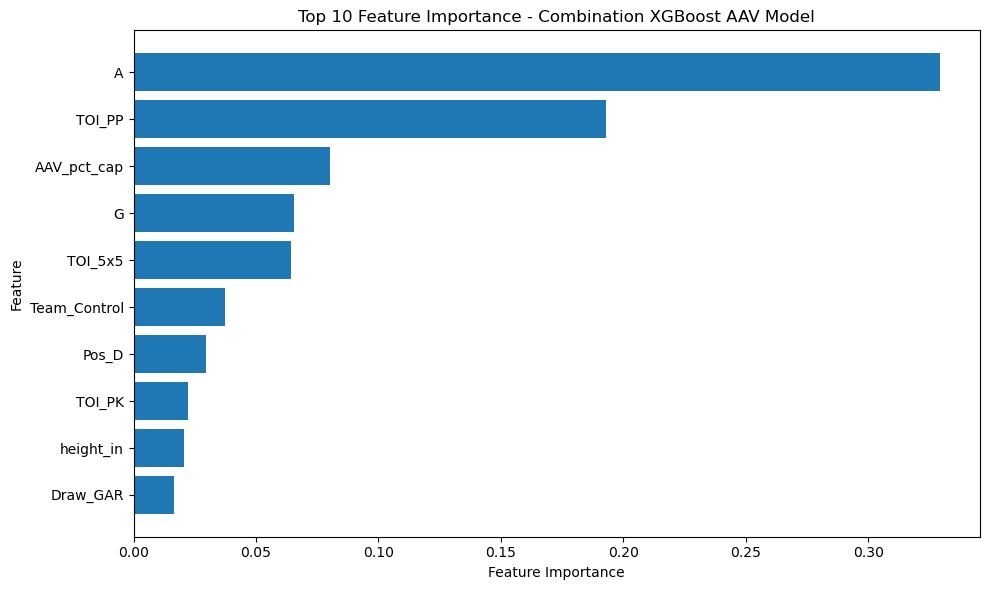

In [138]:
# Get feature importances
importances = xgb3.feature_importances_

# Get feature names (same order as training)
feature_names = xgb_df2[['weight_lbs', 'Draft_Position', 'GP', 'G', 'A', 'PIM', 'height_in', 
                         'TOI_5x5', 'TOI_PP', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 
                         'Take_GAR', 'Draw_GAR', 'TOI_PK', 'Pos_C', 'Pos_D', 'Two_Way', 
                         'Team_Control', 'Expiry_Age_sq', 'Expiry_Age', 'AAV_pct_cap']].columns

# Create dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Get top 10 features
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Sort ascending for horizontal bar chart
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - Combination XGBoost AAV Model')

plt.tight_layout()
#plt.savefig('figure1_xgb_aav_importance.png', dpi=300, bbox_inches='tight')
plt.show()

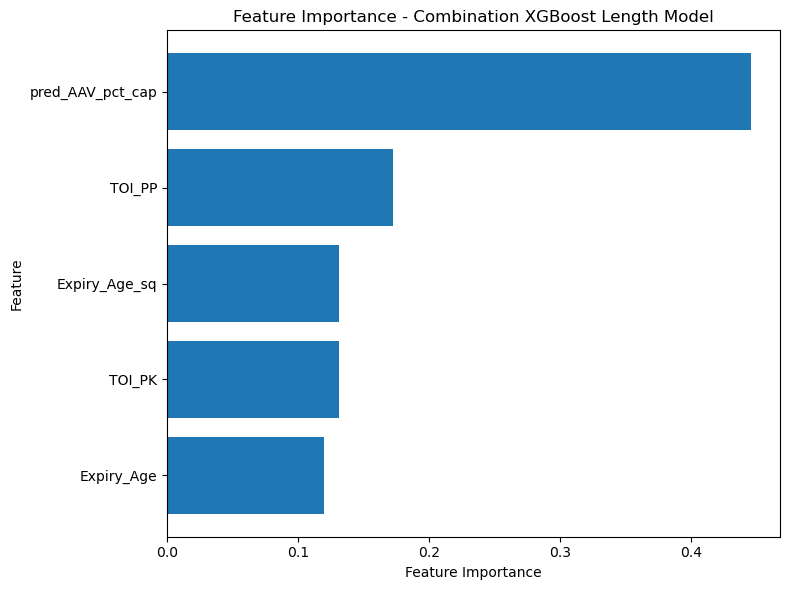

In [139]:
# Get feature importances
importances = xgb4.feature_importances_

# Feature names (must match training order)
feature_names = ['pred_AAV_pct_cap', 'Expiry_Age', 'Expiry_Age_sq', 'TOI_PP', 'TOI_PK']

# Create dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort for clean plotting
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Combination XGBoost Length Model')

plt.tight_layout()
#plt.savefig('figure2_xgb_length_importance.png', dpi=300, bbox_inches='tight')
plt.show()

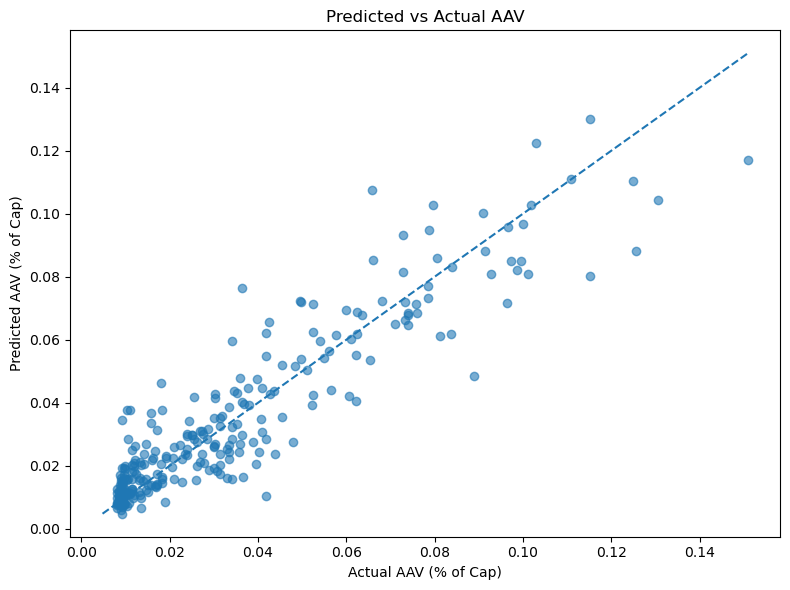

In [140]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test13, y_pred13, alpha=0.6)

# 45-degree reference line
min_val = min(y_test13.min(), y_pred13.min())
max_val = max(y_test13.max(), y_pred13.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

# Labels and title
plt.xlabel('Actual AAV (% of Cap)')
plt.ylabel('Predicted AAV (% of Cap)')
plt.title('Predicted vs Actual AAV')

plt.tight_layout()
#plt.savefig('figure3_pred_vs_actual_aav.png', dpi=300, bbox_inches='tight')
plt.show()

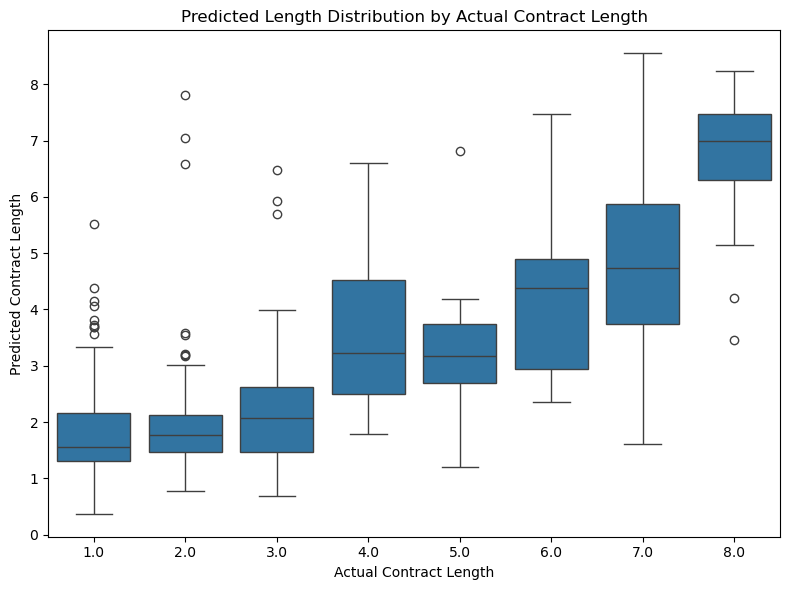

In [141]:
# Create dataframe using variables
plot_df = pd.DataFrame({
    'Actual_Length': y_test14,
    'Predicted_Length': y_pred14
})

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Actual_Length', y='Predicted_Length', data=plot_df)

plt.xlabel('Actual Contract Length')
plt.ylabel('Predicted Contract Length')
plt.title('Predicted Length Distribution by Actual Contract Length')

plt.tight_layout()
#plt.savefig('figure4_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 9 - Dashboard Preparation

In [142]:
# Read in final model results
db = pd.read_csv('xgb_combo_model_results.csv')

# Recreate full name 
db['Full_Name'] = db['First_Name'] + ' ' + db['Last_Name']

# Recreate position
db["Position"] = np.select(
    [
        (db["Pos_C"] == 1) & (db["Pos_D"] == 0),
        (db["Pos_C"] == 0) & (db["Pos_D"] == 1),
        (db["Pos_C"] == 0) & (db["Pos_D"] == 0),
    ],
    ["Center", "Defenseman", "Winger"],
    default="Unknown")

# Create team_end_season varriable
db["Team_End_Season"] = (
    db["Team"]
    .str.split("/")
    .str[-1]
    .str.replace(r"[^\w]", "", regex=True))

# Change Arizona contrracts to Utah
db["Team_End_Season"] = db["Team_End_Season"].replace({"ARI": "UTA"})

db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Birthdate           940 non-null    object 
 1   Shot                940 non-null    int64  
 2   weight_lbs          940 non-null    int64  
 3   Draft_Position      940 non-null    float64
 4   Length              940 non-null    int64  
 5   AAV                 940 non-null    int64  
 6   Expiry Status       940 non-null    object 
 7   GP                  940 non-null    float64
 8   G                   940 non-null    float64
 9   A                   940 non-null    float64
 10  P                   940 non-null    float64
 11  PIM                 940 non-null    float64
 12  GF_pct              940 non-null    float64
 13  CF_pct              940 non-null    float64
 14  Season              940 non-null    int64  
 15  Next_Year           940 non-null    int64  
 16  next_aav

In [143]:
# Export file for dashboard usage
db.to_csv('DASHBOARD.csv', index=False)

In [144]:
db["Team_End_Season"].nunique(dropna=False)

32